<a href="https://colab.research.google.com/github/zdneptr-clx/Alprog-5B/blob/main/ALPROG_5B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import files
uploaded = files.upload()

Saving Kelas B_CO2 Emissions by Car.csv to Kelas B_CO2 Emissions by Car.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('Kelas B_CO2 Emissions by Car.csv', sep=';')

In [ ]:
df.head()

,MODEL_YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301


In [ ]:
df.columns

Index(['MODEL_YEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE_SIZE',
       'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL_CONSUMPTION*',
       'CO2_EMISSIONS'],
      dtype='object')

In [ ]:
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679 entries, 0 to 678
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MODEL_YEAR         679 non-null    int64  
 1   MAKE               679 non-null    object 
 2   MODEL              679 non-null    object 
 3   VEHICLE CLASS      679 non-null    object 
 4   ENGINE_SIZE        679 non-null    float64
 5   CYLINDERS          679 non-null    int64  
 6   TRANSMISSION       679 non-null    object 
 7   FUEL               679 non-null    object 
 8   FUEL_CONSUMPTION*  679 non-null    float64
 9   CO2_EMISSIONS      679 non-null    int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 53.2+ KB
None
       MODEL_YEAR  ENGINE_SIZE   CYLINDERS  FUEL_CONSUMPTION*  CO2_EMISSIONS
count       679.0   679.000000  679.000000         679.000000     679.000000
mean       2001.0     3.252577    5.798233          14.591900     293.656848
std           0.0   

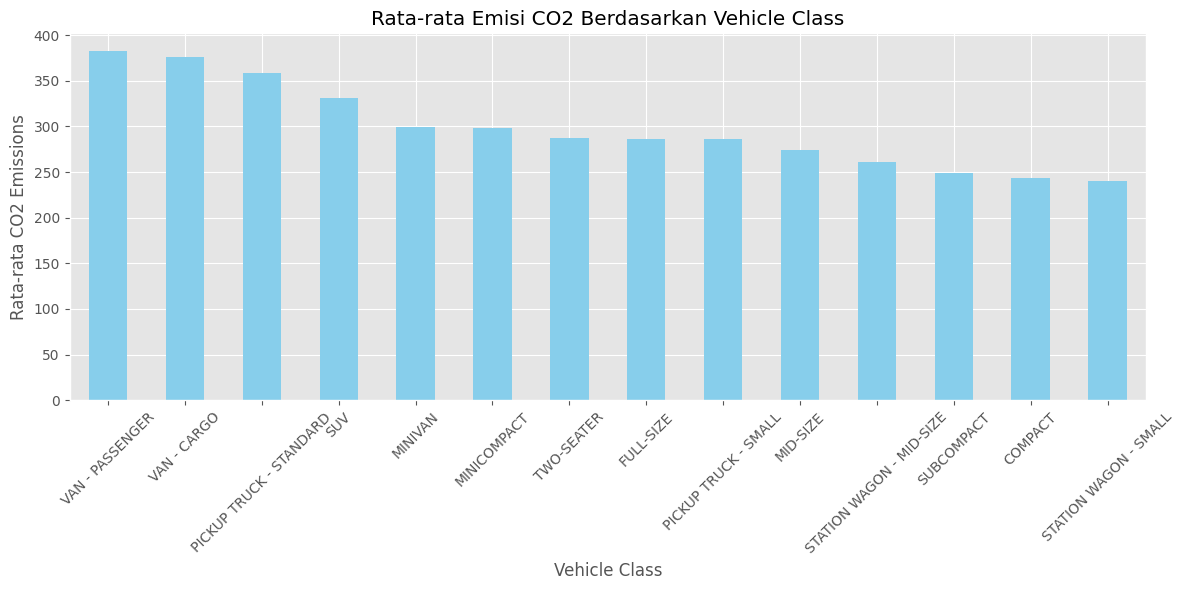

Kategori A (Agregasi)
Grafik menunjukkan rata-rata emisi CO2 pada setiap kelas kendaraan.
Semakin tinggi batang, semakin besar rata-rata emisi CO2 kendaraan pada kelas tersebut.


In [ ]:
# AGREGASI
agregasi = (
    df.groupby('VEHICLE CLASS')['CO2_EMISSIONS']
    .mean()
    .sort_values(ascending=False)
)

# Membuat figure dan axes
fig, ax = plt.subplots(figsize=(12,6))

# Visualisasi
agregasi.plot(
    kind='bar',
    ax=ax,
    color='skyblue'
)

# Judul dan label
ax.set_title('Rata-rata Emisi CO2 Berdasarkan Vehicle Class')
ax.set_xlabel('Vehicle Class')
ax.set_ylabel('Rata-rata CO2 Emissions')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Kategori A (Agregasi)")
print("Grafik menunjukkan rata-rata emisi CO2 pada setiap kelas kendaraan.")
print("Semakin tinggi batang, semakin besar rata-rata emisi CO2 kendaraan pada kelas tersebut.")

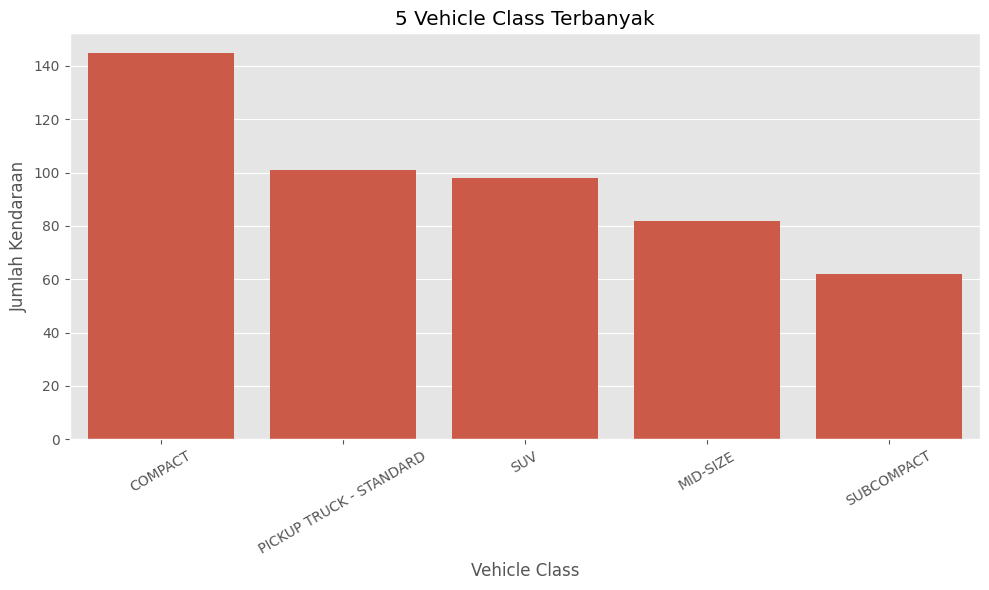

Kategori B (Tren/Filter)
Grafik menampilkan 5 kelas kendaraan yang paling banyak terdapat dalam dataset.
Semakin tinggi batang menunjukkan semakin banyak kendaraan pada kategori tersebut.


In [ ]:
# FILTER: Ambil 5 Vehicle Class dengan jumlah data terbanyak
top5 = df['VEHICLE CLASS'].value_counts().head(5)

# Membuat figure dan axes
fig, ax = plt.subplots(figsize=(10,6))

# Visualisasi
sns.barplot(
    x=top5.index,
    y=top5.values,
    ax=ax
)

# Judul dan label
ax.set_title('5 Vehicle Class Terbanyak')
ax.set_xlabel('Vehicle Class')
ax.set_ylabel('Jumlah Kendaraan')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Kategori B (Tren/Filter)")
print("Grafik menampilkan 5 kelas kendaraan yang paling banyak terdapat dalam dataset.")
print("Semakin tinggi batang menunjukkan semakin banyak kendaraan pada kategori tersebut.")

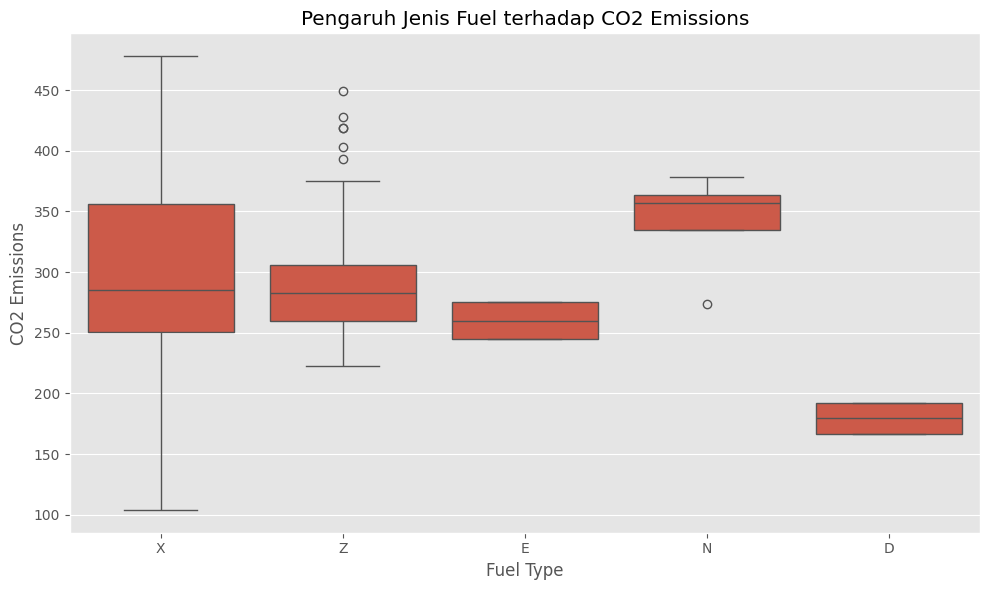

Kategori C (Korelasi)
Grafik menunjukkan hubungan antara jenis bahan bakar (FUEL) dengan emisi CO2.
Setiap box menunjukkan sebaran emisi CO2 pada masing-masing jenis bahan bakar.
Jenis bahan bakar dengan median emisi lebih tinggi cenderung menghasilkan CO2 lebih besar.


In [ ]:
# Membuat figure dan axes
fig, ax = plt.subplots(figsize=(10,6))

# Visualisasi korelasi/pengaruh
sns.boxplot(
    data=df,
    x='FUEL',
    y='CO2_EMISSIONS',
    ax=ax
)

# Judul dan label
ax.set_title('Pengaruh Jenis Fuel terhadap CO2 Emissions')
ax.set_xlabel('Fuel Type')
ax.set_ylabel('CO2 Emissions')

plt.tight_layout()
plt.show()

print("Kategori C (Korelasi)")

print("Grafik menunjukkan hubungan antara jenis bahan bakar (FUEL) dengan emisi CO2.")

print("Setiap box menunjukkan sebaran emisi CO2 pada masing-masing jenis bahan bakar.")

print("Jenis bahan bakar dengan median emisi lebih tinggi cenderung menghasilkan CO2 lebih besar.")

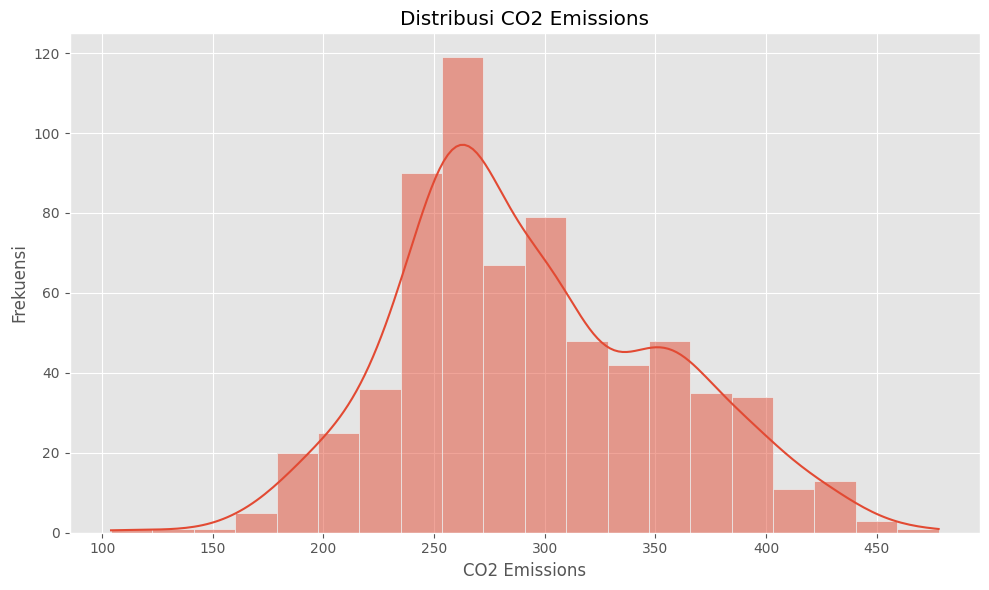

Kategori D (Distribusi)
Grafik menunjukkan sebaran nilai CO2 Emissions pada seluruh kendaraan.
Batang histogram menunjukkan jumlah kendaraan pada rentang emisi tertentu.
Kurva KDE membantu melihat pola distribusi data secara keseluruhan.


In [ ]:
# Membuat figure dan axes
fig, ax = plt.subplots(figsize=(10,6))

# Histogram distribusi
sns.histplot(
    data=df,
    x='CO2_EMISSIONS',
    bins=20,
    kde=True,
    ax=ax
)

# Judul dan label
ax.set_title('Distribusi CO2 Emissions')
ax.set_xlabel('CO2 Emissions')
ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print("Kategori D (Distribusi)")

print("Grafik menunjukkan sebaran nilai CO2 Emissions pada seluruh kendaraan.")

print("Batang histogram menunjukkan jumlah kendaraan pada rentang emisi tertentu.")

print("Kurva KDE membantu melihat pola distribusi data secara keseluruhan.")

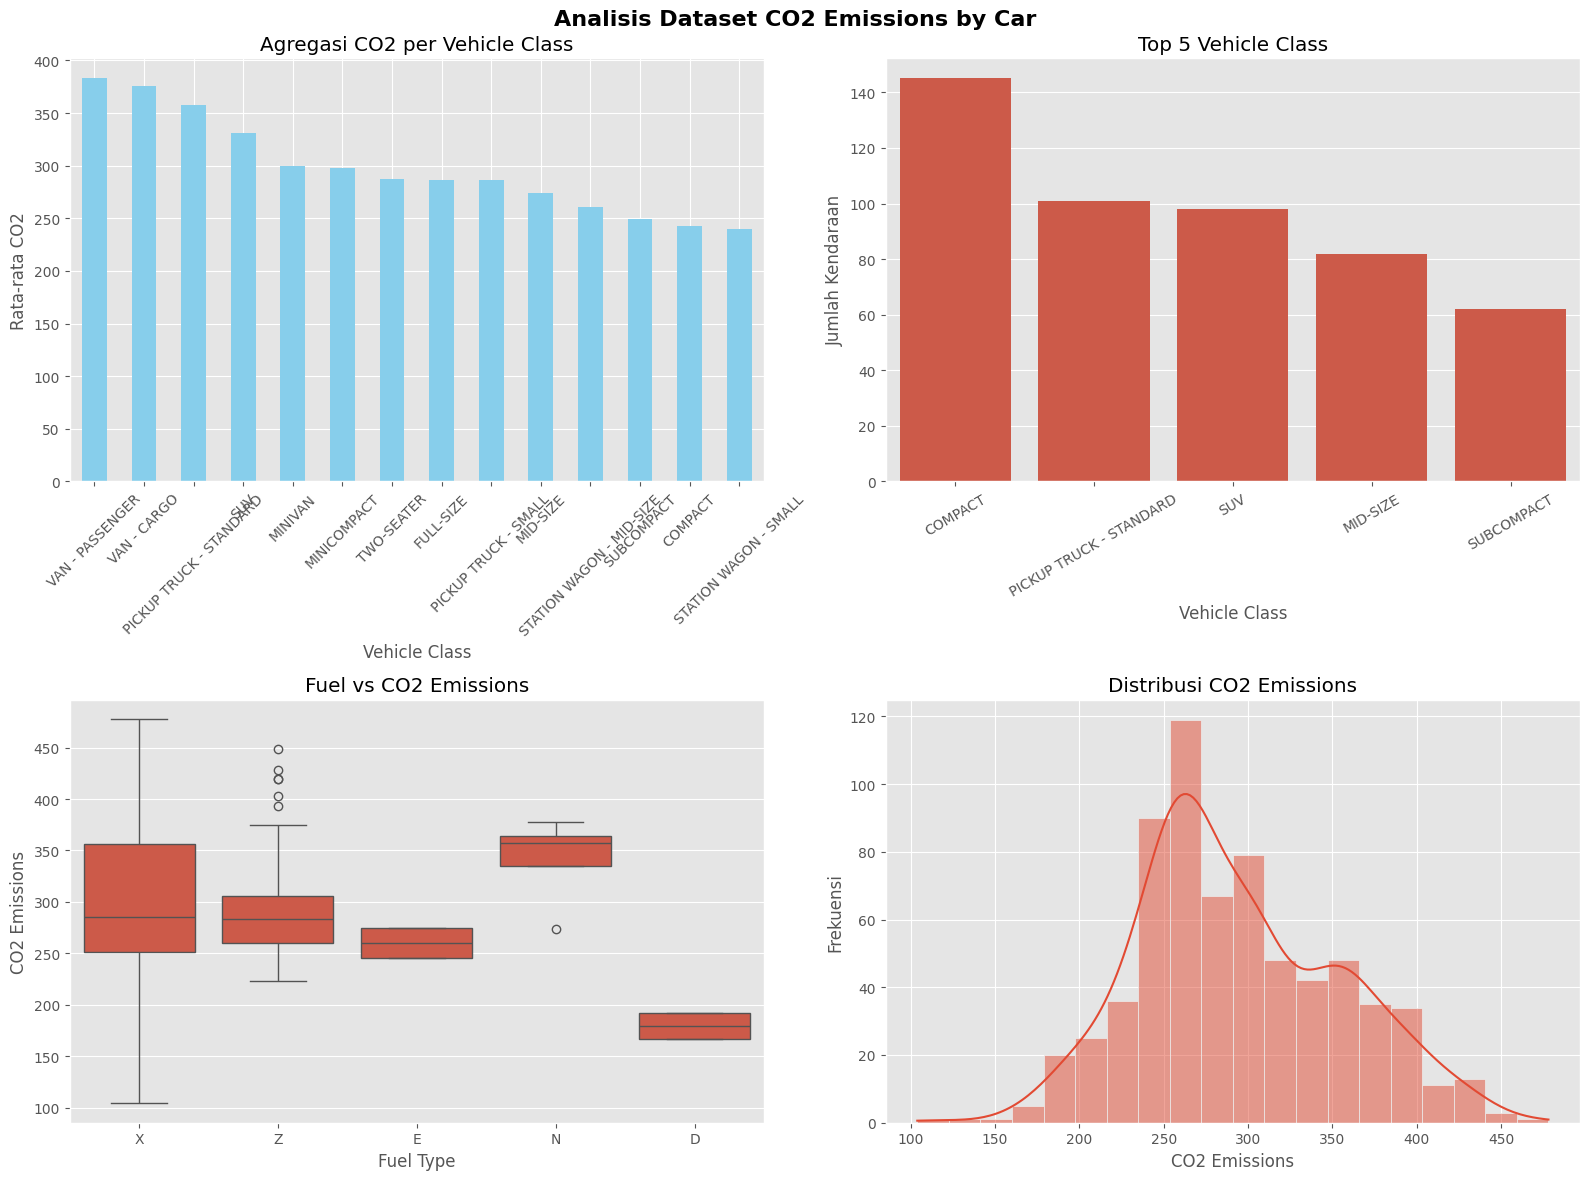

KESIMPULAN ANALISIS DATA
1. Rata-rata emisi CO2 berbeda pada setiap kelas kendaraan.
2. Terdapat 5 kategori kendaraan yang paling dominan dalam dataset.
3. Jenis bahan bakar memiliki pengaruh terhadap tingkat emisi CO2.
4. Distribusi emisi CO2 menunjukkan persebaran kendaraan pada berbagai tingkat emisi.


In [ ]:
# Membuat canvas 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =====================================
# GRAFIK 1 - AGREGASI
# =====================================
agregasi.plot(
    kind='bar',
    ax=axes[0,0],
    color='skyblue'
)

axes[0,0].set_title('Agregasi CO2 per Vehicle Class')
axes[0,0].set_xlabel('Vehicle Class')
axes[0,0].set_ylabel('Rata-rata CO2')
axes[0,0].tick_params(axis='x', rotation=45)

# =====================================
# GRAFIK 2 - FILTER/TREN
# =====================================
sns.barplot(
    x=top5.index,
    y=top5.values,
    ax=axes[0,1]
)

axes[0,1].set_title('Top 5 Vehicle Class')
axes[0,1].set_xlabel('Vehicle Class')
axes[0,1].set_ylabel('Jumlah Kendaraan')
axes[0,1].tick_params(axis='x', rotation=30)

# =====================================
# GRAFIK 3 - KORELASI
# =====================================
sns.boxplot(
    data=df,
    x='FUEL',
    y='CO2_EMISSIONS',
    ax=axes[1,0]
)

axes[1,0].set_title('Fuel vs CO2 Emissions')
axes[1,0].set_xlabel('Fuel Type')
axes[1,0].set_ylabel('CO2 Emissions')

# =====================================
# GRAFIK 4 - DISTRIBUSI
# =====================================
sns.histplot(
    data=df,
    x='CO2_EMISSIONS',
    bins=20,
    kde=True,
    ax=axes[1,1]
)

axes[1,1].set_title('Distribusi CO2 Emissions')
axes[1,1].set_xlabel('CO2 Emissions')
axes[1,1].set_ylabel('Frekuensi')

# =====================================
# TATA LETAK
# =====================================
plt.suptitle(
    'Analisis Dataset CO2 Emissions by Car',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

print("KESIMPULAN ANALISIS DATA")

print("1. Rata-rata emisi CO2 berbeda pada setiap kelas kendaraan.")
print("2. Terdapat 5 kategori kendaraan yang paling dominan dalam dataset.")
print("3. Jenis bahan bakar memiliki pengaruh terhadap tingkat emisi CO2.")
print("4. Distribusi emisi CO2 menunjukkan persebaran kendaraan pada berbagai tingkat emisi.")